<a href="https://colab.research.google.com/github/HimanshiChoubal/Major_Project/blob/master/Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 61.9 MB/s eta 0:00:00


In [2]:
import numpy as np, torch, pennylane as qml, matplotlib.pyplot as plt, time, warnings
from torchvision.datasets import EuroSAT
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

CLASS_A, CLASS_B = "Highway", "River"   # change to any two EuroSAT classes
N_PER_CLASS = 500                        # images per class loaded
N_QUBITS = 4                             # = number of PCA features
SEEDS = 5
TRAIN_SIZES = [8, 16, 32, 64]            # labelled samples used for training

100%|██████████| 94.3M/94.3M [00:00<00:00, 128MB/s]


['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


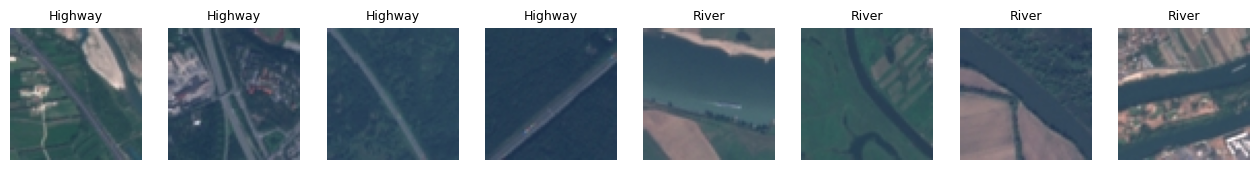

pool: (600, 4) test: (400, 4) | PCA var kept: 0.62


In [3]:
ds = EuroSAT(root="data", download=True)
print(ds.classes)
rng = np.random.default_rng(0)
ia, ib = ds.class_to_idx[CLASS_A], ds.class_to_idx[CLASS_B]
tg = np.array(ds.targets)
ids = np.concatenate([rng.choice(np.where(tg == c)[0], N_PER_CLASS, replace=False) for c in (ia, ib)])

imgs = [ds[i][0] for i in ids]
y = (tg[ids] == ib).astype(int)

fig, ax = plt.subplots(1, 8, figsize=(16, 2.4))
for k, a in enumerate(ax):
    j = k if k < 4 else N_PER_CLASS + k - 4
    a.imshow(imgs[j]); a.axis("off"); a.set_title(CLASS_A if k < 4 else CLASS_B, fontsize=9)
plt.show()

X = np.stack([np.asarray(im.resize((16, 16))) / 255.0 for im in imgs]).reshape(len(imgs), -1)
Xp_raw, Xt_raw, yp, yt = train_test_split(X, y, test_size=0.4, stratify=y, random_state=0)

sc = StandardScaler().fit(Xp_raw)
pca = PCA(N_QUBITS, random_state=0).fit(sc.transform(Xp_raw))
Z = lambda A: pca.transform(sc.transform(A))
mm = MinMaxScaler((0, np.pi)).fit(Z(Xp_raw))
Xp = np.clip(mm.transform(Z(Xp_raw)), 0, np.pi)
Xt = np.clip(mm.transform(Z(Xt_raw)), 0, np.pi)
print("pool:", Xp.shape, "test:", Xt.shape, "| PCA var kept: %.2f" % pca.explained_variance_ratio_.sum())

In [4]:
dev = qml.device("default.qubit", wires=N_QUBITS)

# --- Quantum kernel: ZZ-style feature map, kernel = |<phi(x)|phi(x')>|^2
@qml.qnode(dev)
def fmap_state(x):
    for _ in range(2):
        for i in range(N_QUBITS):
            qml.Hadamard(wires=i); qml.RZ(x[i], wires=i)
        for i in range(N_QUBITS):
            for j in range(i + 1, N_QUBITS):
                qml.CNOT(wires=[i, j]); qml.RZ((np.pi - x[i]) * (np.pi - x[j]), wires=j); qml.CNOT(wires=[i, j])
    return qml.state()

print(qml.draw(fmap_state)(Xp[0]))
t = time.time()
Sp = np.array([fmap_state(x) for x in Xp]); St = np.array([fmap_state(x) for x in Xt])
print("state prep: %.1fs" % (time.time() - t))
kern = lambda A, B: np.abs(A.conj() @ B.T) ** 2

# --- Variational quantum classifier (24 trainable params + 1 bias)
N_LAYERS = 2
@qml.qnode(dev, interface="torch", diff_method="backprop")
def vqc(x, w):
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(w, wires=range(N_QUBITS))
    return qml.expval(qml.PauliZ(0))

def run_vqc(Xtr, ytr, Xte, epochs=80, seed=0):
    torch.manual_seed(seed)
    w = (0.3 * torch.randn(N_LAYERS, N_QUBITS, 3, dtype=torch.float64)).requires_grad_()
    b = torch.zeros(1, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([w, b], lr=0.1)
    Xtr_t = torch.tensor(Xtr, dtype=torch.float64); ytr_t = torch.tensor(2 * ytr - 1, dtype=torch.float64)
    for _ in range(epochs):
        opt.zero_grad(); loss = ((vqc(Xtr_t, w) + b - ytr_t) ** 2).mean(); loss.backward(); opt.step()
    with torch.no_grad():
        return ((vqc(torch.tensor(Xte, dtype=torch.float64), w) + b) > 0).numpy().astype(int)

VQC_PARAMS = N_LAYERS * N_QUBITS * 3 + 1

0: ──H──RZ(1.09)─╭●───────────╭●─╭●───────────╭●─╭●───────────╭●──H──RZ(1.09)─────────────────── ···
1: ──H──RZ(0.75)─╰X──RZ(4.91)─╰X─│────────────│──│────────────│──╭●───────────╭●─╭●───────────╭● ···
2: ──H──RZ(1.58)─────────────────╰X──RZ(3.20)─╰X─│────────────│──╰X──RZ(3.73)─╰X─│────────────│─ ···
3: ──H──RZ(1.46)─────────────────────────────────╰X──RZ(3.46)─╰X─────────────────╰X──RZ(4.03)─╰X ···

0: ··· ──────────────╭●───────────╭●────────╭●───────────╭●─╭●───────────╭●─────────────────── ···
1: ··· ──H──RZ(0.75)─╰X──RZ(4.91)─╰X────────│────────────│──│────────────│──╭●───────────╭●─╭● ···
2: ··· ─╭●───────────╭●──H─────────RZ(1.58)─╰X──RZ(3.20)─╰X─│────────────│──╰X──RZ(3.73)─╰X─│─ ···
3: ··· ─╰X──RZ(2.63)─╰X──H─────────RZ(1.46)─────────────────╰X──RZ(3.46)─╰X─────────────────╰X ···

0: ··· ──────────────────────────────┤  State
1: ··· ───────────╭●─────────────────┤  State
2: ··· ───────────│──╭●───────────╭●─┤  State
3: ··· ──RZ(4.03)─╰X─╰X──RZ(2.63)─╰X─┤  State
state prep: 10

In [5]:
def nparams(m): return sum(c.size for c in m.coefs_) + sum(i.size for i in m.intercepts_)
models = ["RBF-SVM", "MLP (small, ~25 params)", "MLP (large)", "Quantum-Kernel SVM", "VQC (25 params)"]
res = {m: {n: [] for n in TRAIN_SIZES} for m in models}
params = {}

for n in TRAIN_SIZES:
    for s in range(SEEDS):
        r = np.random.default_rng(100 + s)
        sel = np.concatenate([r.choice(np.where(yp == c)[0], n // 2, replace=False) for c in (0, 1)])
        Xtr, ytr = Xp[sel], yp[sel]

        res["RBF-SVM"][n].append((SVC(kernel="rbf").fit(Xtr, ytr).predict(Xt) == yt).mean())

        m = MLPClassifier((4,), max_iter=3000, random_state=s).fit(Xtr, ytr)
        params["MLP (small, ~25 params)"] = nparams(m); res["MLP (small, ~25 params)"][n].append((m.predict(Xt) == yt).mean())

        m = MLPClassifier((64, 64), max_iter=3000, random_state=s).fit(Xtr, ytr)
        params["MLP (large)"] = nparams(m); res["MLP (large)"][n].append((m.predict(Xt) == yt).mean())

        svm = SVC(kernel="precomputed").fit(kern(Sp[sel], Sp[sel]), ytr)
        res["Quantum-Kernel SVM"][n].append((svm.predict(kern(St, Sp[sel])) == yt).mean())

        res["VQC (25 params)"][n].append((run_vqc(Xtr, ytr, Xt, seed=s) == yt).mean())
    print(f"n={n:3d} | " + " | ".join(f"{k}: {np.mean(v[n]):.3f}" for k, v in res.items()))
params["RBF-SVM"] = "n_train (support vecs)"; params["Quantum-Kernel SVM"] = "n_train (support vecs)"; params["VQC (25 params)"] = VQC_PARAMS

n=  8 | RBF-SVM: 0.558 | MLP (small, ~25 params): 0.516 | MLP (large): 0.547 | Quantum-Kernel SVM: 0.574 | VQC (25 params): 0.553
n= 16 | RBF-SVM: 0.561 | MLP (small, ~25 params): 0.508 | MLP (large): 0.560 | Quantum-Kernel SVM: 0.527 | VQC (25 params): 0.563
n= 32 | RBF-SVM: 0.619 | MLP (small, ~25 params): 0.546 | MLP (large): 0.579 | Quantum-Kernel SVM: 0.612 | VQC (25 params): 0.631
n= 64 | RBF-SVM: 0.622 | MLP (small, ~25 params): 0.493 | MLP (large): 0.567 | Quantum-Kernel SVM: 0.598 | VQC (25 params): 0.619


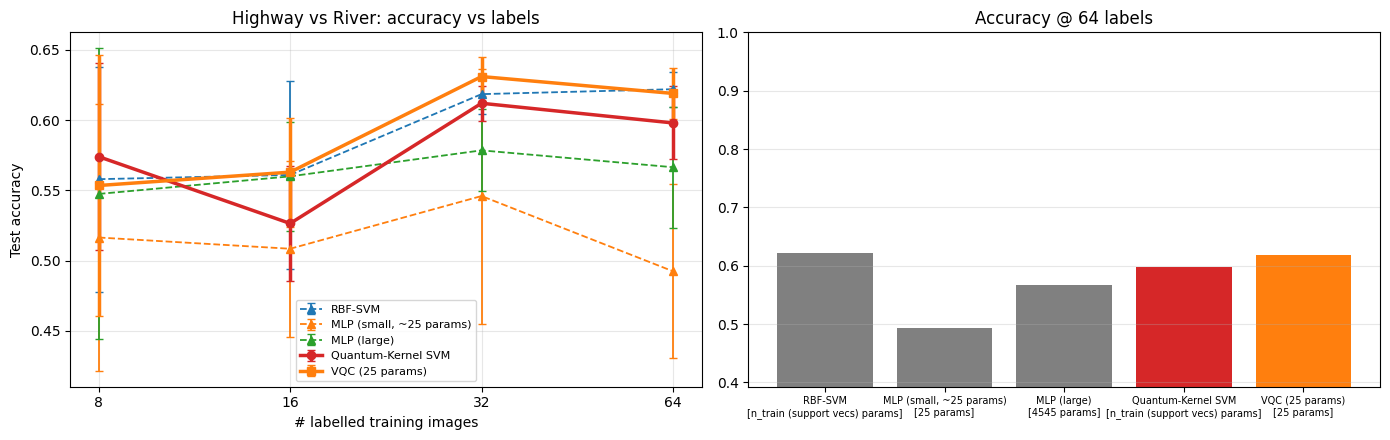

Model                       n=8         n=16        n=32        n=64        
RBF-SVM                     0.558±0.080  0.561±0.067  0.619±0.014  0.622±0.012  
MLP (small, ~25 params)     0.516±0.095  0.508±0.063  0.546±0.091  0.493±0.062  
MLP (large)                 0.547±0.104  0.560±0.039  0.579±0.029  0.567±0.043  
Quantum-Kernel SVM          0.574±0.066  0.527±0.041  0.612±0.013  0.598±0.026  
VQC (25 params)             0.553±0.093  0.563±0.039  0.631±0.014  0.619±0.018  


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
style = {"Quantum-Kernel SVM": ("tab:red", "o-"), "VQC (25 params)": ("tab:orange", "s-")}
for m in models:
    mu = np.array([np.mean(res[m][n]) for n in TRAIN_SIZES]); sd = np.array([np.std(res[m][n]) for n in TRAIN_SIZES])
    c, f = style.get(m, (None, "^--"))
    ax[0].errorbar(TRAIN_SIZES, mu, sd, fmt=f, color=c, capsize=3, label=m, lw=2.5 if c else 1.3)
ax[0].set_xscale("log", base=2); ax[0].set_xticks(TRAIN_SIZES); ax[0].set_xticklabels(TRAIN_SIZES)
ax[0].set_xlabel("# labelled training images"); ax[0].set_ylabel("Test accuracy")
ax[0].set_title(f"{CLASS_A} vs {CLASS_B}: accuracy vs labels"); ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)

n0 = TRAIN_SIZES[-1]
names = [m for m in models]; accs = [np.mean(res[m][n0]) for m in models]
ax[1].bar(range(len(names)), accs, color=["gray", "gray", "gray", "tab:red", "tab:orange"])
ax[1].set_xticks(range(len(names))); ax[1].set_xticklabels([f"{m}\n[{params[m]} params]" for m in names], fontsize=7)
ax[1].set_ylim(min(accs) - .1, 1); ax[1].set_title(f"Accuracy @ {n0} labels"); ax[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

print(f"{'Model':28s}" + "".join(f"n={n:<10d}" for n in TRAIN_SIZES))
for m in models: print(f"{m:28s}" + "".join(f"{np.mean(res[m][n]):.3f}±{np.std(res[m][n]):.3f}  " for n in TRAIN_SIZES))